In [4]:
# ==============================================================================
# 🔍 DATA DIAGNOSTIC & FEATURE ANALYSIS TOOL (BUG FIXED)
# ==============================================================================
import pandas as pd
import numpy as np
import warnings
import re

warnings.filterwarnings('ignore')

print("Loading Data for Analysis...")
df = pd.read_excel('Dataset/train.xlsx')
df.columns = [re.sub(r'[\[\]<>\s]+', '_', str(col)).strip('_').lower() for col in df.columns]

# تبدیل اولیه زمان
df['transaction_timestamp'] = pd.to_datetime(df['transaction_timestamp'], errors='coerce')
df['hour'] = df['transaction_timestamp'].dt.hour
df['day_of_week'] = df['transaction_timestamp'].dt.dayofweek

# تبدیل بولین‌ها
bool_map = {True: 1, False: 0, 'True': 1, 'False': 0, 'TRUE': 1, 'FALSE': 0, 'yes': 1, 'no': 0, 'Y': 1, 'N': 0}
for col in ['is_international', 'unusual_amount_flag', 'multiple_transactions_short_time', 'high_risk_device_flag']:
    if col in df.columns:
        df[col] = df[col].map(bool_map)

# ---------------------------------------------------------
# FIX: پاکسازی ستون‌های عددی از شر کلماتی مثل 'not_available'
# ---------------------------------------------------------
num_cols = ['transaction_amount', 'transaction_frequency_24h', 'avg_transaction_amount_7d', 'failed_transaction_count_24h', 'account_age_days']
for col in num_cols:
    if col in df.columns:
        # errors='coerce' باعث می‌شود هر چیز غیرعددی (مثل 'not_available') تبدیل به NaN شود
        df[col] = pd.to_numeric(df[col], errors='coerce')

# ---------------------------------------------------------
# 1. MISSING VALUES IMPACT
# ---------------------------------------------------------
print("\n" + "="*50)
print(" 🕵️ 1. IMPACT OF MISSING VALUES ON FRAUD")
print("="*50)
for col in df.columns:
    if df[col].isnull().sum() > 0:
        missing_fraud_rate = df[df[col].isnull()]['label'].mean() * 100
        normal_fraud_rate = df[df[col].notnull()]['label'].mean() * 100
        if abs(missing_fraud_rate - normal_fraud_rate) > 2: # فقط اختلافات معنادار
            print(f"Column: {col}")
            print(f"  -> Fraud rate when MISSING: {missing_fraud_rate:.2f}%")
            print(f"  -> Fraud rate when PRESENT: {normal_fraud_rate:.2f}%")

# ---------------------------------------------------------
# 2. CATEGORICAL FRAUD NESTS (Top 3 dangerous categories)
# ---------------------------------------------------------
print("\n" + "="*50)
print(" 🚩 2. MOST DANGEROUS CATEGORIES (FRAUD NESTS)")
print("="*50)
cat_cols = ['payment_method', 'device_type', 'merchant_category', 'location']
for col in cat_cols:
    if col in df.columns:
        stats = df.groupby(col)['label'].agg(['count', 'mean']).reset_index()
        stats = stats[stats['count'] > 50] # فیلتر دسته‌های کوچک
        stats['mean'] = stats['mean'] * 100
        stats = stats.sort_values(by='mean', ascending=False).head(3)
        print(f"\nTop 3 Dangerous [{col}]:")
        for _, row in stats.iterrows():
            print(f"  -> '{row[col]}': {row['mean']:.2f}% Fraud (out of {row['count']} transactions)")

# ---------------------------------------------------------
# 3. NUMERICAL CORRELATIONS & BEHAVIOR
# ---------------------------------------------------------
print("\n" + "="*50)
print(" 🔢 3. NUMERICAL CORRELATION WITH FRAUD")
print("="*50)
# حالا بدون ارور کار می‌کند
corr_df = df[num_cols + ['hour', 'label']].corr(method='spearman')['label'].sort_values(ascending=False)
for idx, val in corr_df.items():
    if idx != 'label':
        print(f"  -> {idx}: {val:.4f}")

print("\n" + "="*50)
print(" 💰 4. TRANSACTION AMOUNT BEHAVIOR")
print("="*50)
fraud_amt = df[df['label'] == 1]['transaction_amount'].dropna()
normal_amt = df[df['label'] == 0]['transaction_amount'].dropna()
print(f"  -> FRAUD Transactions:  Median = {fraud_amt.median():.2f}, 90th Percentile = {fraud_amt.quantile(0.90):.2f}")
print(f"  -> NORMAL Transactions: Median = {normal_amt.median():.2f}, 90th Percentile = {normal_amt.quantile(0.90):.2f}")

Loading Data for Analysis...

 🕵️ 1. IMPACT OF MISSING VALUES ON FRAUD

 🚩 2. MOST DANGEROUS CATEGORIES (FRAUD NESTS)

Top 3 Dangerous [payment_method]:
  -> 'credit card': 55.66% Fraud (out of 106 transactions)
  -> 'GooglePay': 53.45% Fraud (out of 116 transactions)
  -> 'pay_pal': 52.85% Fraud (out of 123 transactions)

Top 3 Dangerous [device_type]:
  -> 'mobile': 52.91% Fraud (out of 189 transactions)
  -> 'Mobile ': 52.17% Fraud (out of 184 transactions)
  -> 'Mobile': 51.87% Fraud (out of 24497 transactions)

Top 3 Dangerous [merchant_category]:
  -> 'gaming': 55.75% Fraud (out of 113 transactions)
  -> 'Gaming ': 52.63% Fraud (out of 95 transactions)
  -> 'electronics': 52.08% Fraud (out of 96 transactions)

Top 3 Dangerous [location]:
  -> 'australia': 55.45% Fraud (out of 101 transactions)
  -> 'AUSTRALIA': 54.90% Fraud (out of 102 transactions)
  -> ' usa ': 52.88% Fraud (out of 104 transactions)

 🔢 3. NUMERICAL CORRELATION WITH FRAUD
  -> transaction_frequency_24h: 0.3147


In [1]:
# ==============================================================================
# 🕵️ ADVERSARIAL VALIDATION (TRAIN vs TEST DISTRIBUTION CHECK)
# ==============================================================================
import pandas as pd
import numpy as np
import warnings
import re
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

warnings.filterwarnings('ignore')

print("⏳ Loading Data...")
train = pd.read_excel('Dataset/train.xlsx')
test = pd.read_excel('Dataset/student_test.xlsx')

# استانداردسازی نام ستون‌ها
train.columns = [re.sub(r'[\[\]<>\s]+', '_', str(col)).strip('_').lower() for col in train.columns]
test.columns = [re.sub(r'[\[\]<>\s]+', '_', str(col)).strip('_').lower() for col in test.columns]

# علامت‌گذاری داده‌ها (مسئله اصلی Adversarial Validation)
train['is_test'] = 0
test['is_test'] = 1

# حذف لیبل اصلی تقلب چون الان باهاش کاری نداریم
train = train.drop(columns=['label'], errors='ignore')

# ترکیب دو دیتاست برای بررسی تفاوت‌ها
df = pd.concat([train, test], axis=0, ignore_index=True)

print("⏳ Cleaning & Normalizing Data...")
cat_cols = ['payment_method', 'device_type', 'merchant_category', 'location']
for col in cat_cols:
    df[col] = df[col].astype(str).str.lower().str.strip()
    df[col] = df[col].replace({'nan': 'missing', 'none': 'missing', '': 'missing'})
    
    # کدگذاری فرکانسی ایمن
    freq_dict = df[col].value_counts(normalize=True).to_dict()
    df[f'{col}_freq'] = df[col].map(freq_dict)
    df.drop(columns=[col], inplace=True)

bool_map = {True: 1, False: 0, 'True': 1, 'False': 0, 'TRUE': 1, 'FALSE': 0, 'yes': 1, 'no': 0, 'Y': 1, 'N': 0}
for col in ['is_international', 'unusual_amount_flag', 'multiple_transactions_short_time', 'high_risk_device_flag']:
    if col in df.columns:
        df[col] = df[col].map(bool_map).fillna(-1).astype(int)

num_cols = ['transaction_amount', 'transaction_frequency_24h', 'avg_transaction_amount_7d', 'failed_transaction_count_24h', 'account_age_days']
for col in num_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# ویژگی‌های ریاضی (ببینیم آیا این فرمول‌ها در تست تغییر رفتار میدهند؟)
df['freq_to_fail_ratio'] = df['transaction_frequency_24h'] / (df['failed_transaction_count_24h'] + 1e-5)
df['amount_z_score'] = (df['transaction_amount'] - df['avg_transaction_amount_7d']) / (df['avg_transaction_amount_7d'].abs() + 1e-5)
df['risk_sum'] = df[['is_international', 'unusual_amount_flag', 'multiple_transactions_short_time', 'high_risk_device_flag']].sum(axis=1)
df['log_amount'] = np.log1p(df['transaction_amount'].clip(lower=0))

# حذف ستون‌های خام که تبدیل شده‌اند یا بی‌تاثیرند
drop_cols = ['transaction_timestamp', 'transaction_id', 'customer_id', 'hour', 'is_test', 'transaction_amount']
features = [c for c in df.columns if c not in drop_cols]

X_adv = df[features]
y_adv = df['is_test']

print("⏳ Running Adversarial Model (Can it separate Train from Test?)...")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(X_adv))
feature_importances = np.zeros(len(features))

for train_idx, val_idx in skf.split(X_adv, y_adv):
    X_tr, X_va = X_adv.iloc[train_idx], X_adv.iloc[val_idx]
    y_tr, y_va = y_adv.iloc[train_idx], y_adv.iloc[val_idx]
    
    # یک مدل برای پیدا کردن جاسوس‌ها
    model = LGBMClassifier(n_estimators=100, learning_rate=0.05, random_state=42, n_jobs=-1, verbose=-1)
    model.fit(X_tr, y_tr)
    
    oof_preds[val_idx] = model.predict_proba(X_va)[:, 1]
    feature_importances += model.feature_importances_ / 5

auc_score = roc_auc_score(y_adv, oof_preds)

print("\n" + "="*50)
print(f"🚨 ADVERSARIAL AUC SCORE: {auc_score:.4f} 🚨")
print("="*50)
if auc_score > 0.60:
    print("-> WARNING: The model CAN easily distinguish Train from Test.")
    print("-> This means some features have completely different distributions in the Test set.")
else:
    print("-> GOOD NEWS: Train and Test sets look very similar (AUC is close to 0.5).")

imp_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})
imp_df = imp_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)

print("\n🕵️ TOP 10 FEATURES CAUSING THE DRIFT (The Spies):")
print(imp_df.head(10))

⏳ Loading Data...
⏳ Cleaning & Normalizing Data...
⏳ Running Adversarial Model (Can it separate Train from Test?)...

🚨 ADVERSARIAL AUC SCORE: 1.0000 🚨
-> WARNING: The model CAN easily distinguish Train from Test.
-> This means some features have completely different distributions in the Test set.

🕵️ TOP 10 FEATURES CAUSING THE DRIFT (The Spies):
                        Feature  Importance
0     transaction_frequency_24h       178.8
1                            id       107.4
2     avg_transaction_amount_7d        53.6
3              is_international        36.2
4              account_age_days        25.0
5                amount_z_score        10.2
6            freq_to_fail_ratio         8.4
7  failed_transaction_count_24h         6.4
8                    log_amount         6.0
9           payment_method_freq         1.0


In [ ]:
# ==============================================================================
# 🚀 END-TO-END FRAUD PIPELINE (V14 - SPY CATCHER + V13 HEAVY ENSEMBLE)
# ==============================================================================
import pandas as pd
import numpy as np
import warnings
import re
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.ensemble import (HistGradientBoostingClassifier, RandomForestClassifier, 
                              ExtraTreesClassifier)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_curve
from sklearn.preprocessing import RobustScaler

warnings.filterwarnings('ignore')
SEED = 2024

print("⏳ [1/6] Loading & Normalizing Data...")
train_df = pd.read_excel('Dataset/train.xlsx')
test_df = pd.read_excel('Dataset/student_test.xlsx')

def clean_column_names(df):
    df.columns = [re.sub(r'[\[\]<>\s]+', '_', str(col)).strip('_').lower() for col in df.columns]
    return df

train_df = clean_column_names(train_df)
test_df = clean_column_names(test_df)

print("⏳ [2/6] Clean Preprocessing & EXECUTING THE SPIES...")
def safe_data_pipeline(df):
    df = df.copy()
    
    # 1. تمیزکاری متون
    cat_cols = ['payment_method', 'device_type', 'merchant_category', 'location']
    for col in cat_cols:
        if col in df.columns:
            df[col] = df[col].astype(str).str.lower().str.strip()
            df[col] = df[col].replace({'nan': 'missing', 'none': 'missing', '': 'missing'})
            
    # 2. تبدیل بولین‌های امن
    bool_map = {True: 1, False: 0, 'True': 1, 'False': 0, 'TRUE': 1, 'FALSE': 0, 'yes': 1, 'no': 0, 'Y': 1, 'N': 0}
    safe_bools = ['unusual_amount_flag', 'multiple_transactions_short_time', 'high_risk_device_flag']
    for col in safe_bools:
        if col in df.columns:
            df[col] = df[col].map(bool_map).fillna(-1).astype(int)
            
    # 3. تبدیل اعداد امن
    safe_nums = ['transaction_amount', 'failed_transaction_count_24h', 'account_age_days']
    for col in safe_nums:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)
            
    # 🚨 4. اعدام ویژگی‌های خائن (بر اساس Adversarial Validation) 🚨
    spies_to_drop = [
        'transaction_timestamp', 'transaction_id', 'customer_id', 'hour', # ویژگی‌های بلااستفاده
        'transaction_frequency_24h', # خائن شماره 1
        'avg_transaction_amount_7d', # خائن شماره 2
        'is_international',          # خائن شماره 3
        'id'                         # شناسه تست
    ]
    df.drop(columns=spies_to_drop, errors='ignore', inplace=True)
    
    # 5. ویژگی‌های ریاضی جدید (فقط بر اساس داده‌های امن)
    df['risk_sum_safe'] = df[safe_bools].sum(axis=1)
    df['log_amount'] = np.log1p(df['transaction_amount'].clip(lower=0))
    
    return df

train_clean = safe_data_pipeline(train_df)
test_clean = safe_data_pipeline(test_df)

print("⏳ [3/6] Smoothed Target Encoding (Safe Features Only)...")
global_mean = train_clean['label'].mean()
cat_cols = ['payment_method', 'device_type', 'merchant_category', 'location']

for col in cat_cols:
    if col in train_clean.columns:
        agg = train_clean.groupby(col)['label'].agg(['count', 'mean'])
        smooth_enc = (agg['count'] * agg['mean'] + 10 * global_mean) / (agg['count'] + 10)
        train_clean[f'{col}_smooth_enc'] = train_clean[col].map(smooth_enc)
        test_clean[f'{col}_smooth_enc'] = test_clean[col].map(smooth_enc).fillna(global_mean)
        train_clean.drop(columns=[col], inplace=True)
        test_clean.drop(columns=[col], inplace=True)

drop_from_train = ['label', 'transaction_amount'] # مبلغ خام حذف می‌شود چون لگاریتم داریم
train_features = [col for col in train_clean.columns if col not in drop_from_train]

X = train_clean[train_features].replace([np.inf, -np.inf], 0).fillna(0)
y = train_clean['label']

for col in train_features:
    if col not in test_clean.columns:
        test_clean[col] = 0
X_test = test_clean[train_features].replace([np.inf, -np.inf], 0).fillna(0)

# استانداردسازی مقیاس‌ها
scaler = RobustScaler()
X = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

print(f"  -> Features ready: {X.shape[1]} columns. Spies have been eliminated!")

print("⏳ [4/6] DEEP Tuning of All 6 Models (V13 Settings Preserved)...")
scale_ratio = (len(y) - y.sum()) / y.sum()

grids = {
    'LightGBM': (LGBMClassifier(scale_pos_weight=scale_ratio, random_state=SEED, n_jobs=-1, verbose=-1),
                 {'learning_rate': [0.01, 0.03, 0.05, 0.1], 'n_estimators': [200, 300, 400, 500], 'max_depth': [5, 7, 9, -1], 'num_leaves': [15, 31, 63]}),
    
    'XGBoost': (XGBClassifier(scale_pos_weight=scale_ratio, random_state=SEED, n_jobs=-1, eval_metric='logloss'),
                {'learning_rate': [0.01, 0.03, 0.05, 0.1], 'n_estimators': [200, 300, 400, 500], 'max_depth': [5, 7, 9]}),
    
    'CatBoost': (CatBoostClassifier(auto_class_weights='Balanced', random_state=SEED, verbose=0, thread_count=-1),
                 {'learning_rate': [0.01, 0.03, 0.05, 0.1], 'iterations': [200, 300, 400, 500], 'depth': [5, 7, 9]}),
    
    'HistGB': (HistGradientBoostingClassifier(class_weight='balanced', random_state=SEED),
               {'learning_rate': [0.01, 0.03, 0.05, 0.1], 'max_iter': [200, 300, 400, 500], 'max_depth': [5, 7, 9, None]}),
               
    'RandomForest': (RandomForestClassifier(class_weight='balanced', random_state=SEED, n_jobs=-1),
                     {'n_estimators': [300, 400, 500], 'max_depth': [10, 20, 30, None], 
                      'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 4], 'max_features': ['sqrt', 'log2']}),
                      
    'ExtraTrees': (ExtraTreesClassifier(class_weight='balanced', random_state=SEED, n_jobs=-1),
                   {'n_estimators': [300, 400, 500], 'max_depth': [10, 20, 30, None], 
                    'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 4], 'max_features': ['sqrt', 'log2']})
}

best_models = {}
model_cv_scores = {}
skf_tune = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

for name, (model, params) in grids.items():
    search = RandomizedSearchCV(estimator=model, param_distributions=params, n_iter=25, 
                                scoring='f1', cv=skf_tune, random_state=SEED, n_jobs=-1, verbose=0)
    search.fit(X, y)
    best_models[name] = search.best_estimator_
    model_cv_scores[name] = search.best_score_
    print(f"  ✅ {name} Tuned! (5-Fold F1: {search.best_score_:.4f})")

print("\n⏳ [5/6] Generating Strict OOF Matrix for Ensembles (5-Fold)...")
skf_oof = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
num_models = len(best_models)
oof_matrix = np.zeros((len(X), num_models))
test_matrix = np.zeros((len(X_test), num_models))
model_names = list(best_models.keys())

for i, name in enumerate(model_names):
    model = best_models[name]
    for tr_idx, val_idx in skf_oof.split(X, y):
        model.fit(X.iloc[tr_idx], y.iloc[tr_idx])
        oof_matrix[val_idx, i] = model.predict_proba(X.iloc[val_idx])[:, 1]
    
    model.fit(X, y)
    test_matrix[:, i] = model.predict_proba(X_test)[:, 1]

print("\n⏳ [6/6] Applying 3 Ensemble Strategies...")

def optimize_and_save(probs_train, probs_test, filename, method_name):
    prec, rec, thresh = precision_recall_curve(y, probs_train)
    f1s = 2 * (prec * rec) / (prec + rec + 1e-10)
    opt_idx = np.argmax(f1s)
    opt_t = thresh[opt_idx]
    max_f1 = f1s[opt_idx]
    
    preds = (probs_test >= opt_t).astype(int)
    pd.DataFrame({'id': test_df['id'].astype(int), 'label': preds}).to_csv(filename, index=False)
    print(f"  -> {method_name} | Max OOF F1: {max_f1:.4f} | Optimal Thresh: {opt_t:.4f}")

# ۱. میانگین ساده
simple_oof = np.mean(oof_matrix, axis=1)
simple_test = np.mean(test_matrix, axis=1)
optimize_and_save(simple_oof, simple_test, 'Dataset/submission_V14_1_Safe_Mean.csv', 'Safe Mean')

# ۲. میانگین وزنی
scores = np.array(list(model_cv_scores.values()))
weights = scores / np.sum(scores) 
weighted_oof = np.dot(oof_matrix, weights)
weighted_test = np.dot(test_matrix, weights)
optimize_and_save(weighted_oof, weighted_test, 'Dataset/submission_V14_2_Safe_Weighted.csv', 'Safe Weighted')

# ۳. استکینگ
meta_model = LogisticRegression(class_weight='balanced', random_state=SEED, C=0.5)
meta_model.fit(oof_matrix, y)
stacking_oof = meta_model.predict_proba(oof_matrix)[:, 1]
stacking_test = meta_model.predict_proba(test_matrix)[:, 1]
optimize_and_save(stacking_oof, stacking_test, 'Dataset/submission_V14_3_Safe_Stacking.csv', 'Safe Stacking')

print("\n🎯 THE SPY CATCHER RUN IS COMPLETE! Upload the Weighted or Stacking file.")

⏳ [1/6] Loading & Normalizing Data...
⏳ [2/6] Clean Preprocessing & EXECUTING THE SPIES...
⏳ [3/6] Smoothed Target Encoding (Safe Features Only)...
  -> Features ready: 11 columns. Spies have been eliminated!
⏳ [4/6] DEEP Tuning of All 6 Models (V13 Settings Preserved)...
  ✅ LightGBM Tuned! (5-Fold F1: 0.7146)
  ✅ XGBoost Tuned! (5-Fold F1: 0.7137)
  ✅ CatBoost Tuned! (5-Fold F1: 0.7148)
  ✅ HistGB Tuned! (5-Fold F1: 0.7142)
  ✅ RandomForest Tuned! (5-Fold F1: 0.7115)


KeyboardInterrupt: 

: 

# Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import warnings
import re
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

print("Part 1: Libraries imported successfully!")

Part 1: Libraries imported successfully!


In [2]:
train_path = 'Dataset/train.xlsx'
test_path = 'Dataset/student_test.xlsx'

train_df = pd.read_excel(train_path)
test_df = pd.read_excel(test_path)

def clean_column_names(df):
    df.columns = [re.sub(r'[\[\]<>\s]+', '_', col).strip('_').lower() for col in df.columns]
    s = pd.Series(df.columns)
    dup = s.groupby(s).cumcount()
    df.columns = s + np.where(dup == 0, '', '_' + dup.astype(str))
    return df

train_df = clean_column_names(train_df)
test_df = clean_column_names(test_df)

print(f"Train data shape: {train_df.shape}")
print(f"Test data shape:  {test_df.shape}")
print("Part 2: Data loaded and columns standardized!")

Train data shape: (80000, 17)
Test data shape:  (20000, 17)
Part 2: Data loaded and columns standardized!


In [3]:
# ==========================================
# سلول ۳: پیش‌پردازش پایه (اصلاح شده برای حفظ سیگنال‌های گمشده)
# ==========================================
def base_preprocessing(df):
    df = df.copy()
    
    df['transaction_timestamp'] = pd.to_datetime(df['transaction_timestamp'], errors='coerce')
    df['hour'] = df['transaction_timestamp'].dt.hour
    df['day_of_week'] = df['transaction_timestamp'].dt.dayofweek
    
    bool_mapping = {True: 1, False: 0, 'True': 1, 'False': 0, 'TRUE': 1, 'FALSE': 0, 'yes': 1, 'no': 0, 'Y': 1, 'N': 0}
    boolean_cols = ['is_international', 'unusual_amount_flag', 'multiple_transactions_short_time', 'high_risk_device_flag']
    
    for col in boolean_cols:
        if col in df.columns:
            df[col] = df[col].map(bool_mapping).fillna(-1).astype(int) # -1 برای مقادیر نامشخص بولین
            
    numerical_cols = [
        'transaction_amount', 'transaction_frequency_24h', 
        'avg_transaction_amount_7d', 'failed_transaction_count_24h', 
        'account_age_days'
    ]
    for col in numerical_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
            # استراتژی جدید: پر کردن با -999 به جای میانه برای حفظ ردپای تقلب
            df[col] = df[col].fillna(-999) 
            
    categorical_cols = ['payment_method', 'device_type', 'merchant_category', 'location']
    for col in categorical_cols:
        if col in df.columns:
            df[col] = df[col].fillna('Missing')
            
    return df

train_clean = base_preprocessing(train_df)
test_clean = base_preprocessing(test_df)

print("Part 3 (Revised): Base preprocessing completed with -999 strategy!")
display(train_clean.head(2))

Part 3 (Revised): Base preprocessing completed with -999 strategy!


,transaction_id,customer_id,transaction_timestamp,transaction_amount,payment_method,device_type,location,merchant_category,is_international,transaction_frequency_24h,avg_transaction_amount_7d,failed_transaction_count_24h,account_age_days,unusual_amount_flag,multiple_transactions_short_time,high_risk_device_flag,label,hour,day_of_week
0,T0000429,C18117,2025-04-30 19:56:23.688247,209.35,PayPal,Mobile,Canada,Groceries,-1,14.0,100.50,3.0,1499.0,1,-1,0,1,19,2
1,T0000802,C12701,2025-04-30 19:56:23.696115,330.37,Google Pay,Mobile,Canada,Electronics,0,9.0,101.05,0.0,1683.0,1,-1,0,0,19,2


--- Missing Values Pattern (Fraud vs Normal) ---


label,0,1
avg_transaction_amount_7d,2.27,2.42
transaction_amount,2.24,2.36
failed_transaction_count_24h,1.80,1.76
account_age_days,1.83,1.70
transaction_frequency_24h,1.78,1.70
device_type,1.01,1.06
payment_method,0.98,1.05
location,1.00,1.04



--- Correlation with Target (Label) ---


,Correlation with Label
label,1.000000
is_international,0.229769
multiple_transactions_short_time,0.193875
unusual_amount_flag,0.178477
high_risk_device_flag,0.056442
transaction_amount,0.020604
transaction_frequency_24h,0.011381
day_of_week,0.002807
account_age_days,0.002146
failed_transaction_count_24h,0.002030



--- Transaction Amount Distribution ---


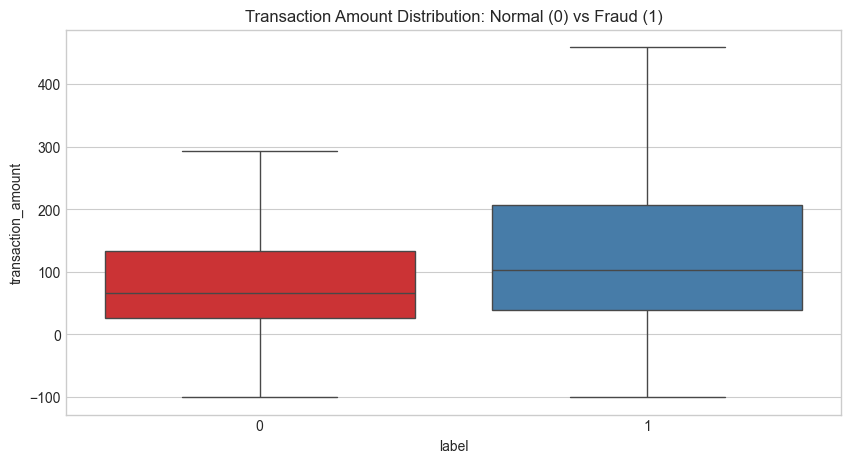

In [4]:
# ==========================================
# سلول ۳.۵: فاز اکتشاف داده‌ها (رفع باگ شده)
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. تحلیل مقادیر گمشده (روی داده‌های خام تا ببینیم در اصل چقدر خالی بوده)
print("--- Missing Values Pattern (Fraud vs Normal) ---")
missing_df = train_df.isnull().groupby(train_df['label']).mean() * 100
display(missing_df.T.sort_values(by=1, ascending=False).head(8).round(2))

# 2. تحلیل همبستگی با استفاده از داده‌های تمیز شده (عددی)
print("\n--- Correlation with Target (Label) ---")
numeric_cols = train_clean.select_dtypes(include=['float64', 'int64', 'int32']).columns
correlations = train_clean[numeric_cols].corr()['label'].sort_values(ascending=False)
display(pd.DataFrame({'Correlation with Label': correlations}))

# 3. بررسی توزیع مبلغ تراکنش (روی اعداد واقعی)
print("\n--- Transaction Amount Distribution ---")
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=train_clean, 
    x='label', 
    y='transaction_amount', 
    showfliers=False, 
    palette='Set1'
)
plt.title('Transaction Amount Distribution: Normal (0) vs Fraud (1)')
plt.show()

In [12]:
# ==========================================
# سلول ۴: مهندسی ویژگی‌ها (نسخه V3 - تغییر عملگرها به جمع و تفریق)
# ==========================================
import numpy as np

def advanced_feature_engineering_v3(df):
    df = df.copy()
    
    # 1. Log Transform (بسیار مهم برای مبالغ مالی جهت کاهش اثر داده‌های پرت)
    # از clip استفاده میکنیم تا اعداد منفی باعث ارور نشوند
    df['log_transaction_amount'] = np.log1p(df['transaction_amount'].clip(lower=0))
    
    # 2. استفاده از تفریق (Difference) به جای نسبت خالص
    df['amount_diff_avg_7d'] = df['transaction_amount'] - df['avg_transaction_amount_7d']
    df['amount_to_avg_7d_ratio'] = df['transaction_amount'] / (df['avg_transaction_amount_7d'] + 1e-5)
    
    # 3. ریسک‌های تجمیعی (استفاده از جمع به جای ضرب طبق ایده شما)
    df['risk_sum_multi_short'] = df['is_international'] + df['multiple_transactions_short_time']
    df['risk_sum_unusual'] = df['is_international'] + df['unusual_amount_flag']
    
    # 4. ریسک کلی
    risk_cols = ['is_international', 'unusual_amount_flag', 'multiple_transactions_short_time', 'high_risk_device_flag']
    df['total_risk_score'] = df[risk_cols].sum(axis=1)
    
    # 5. فشار تراکنشی
    df['amount_per_freq'] = df['transaction_amount'] / (df['transaction_frequency_24h'] + 1e-5)
    
    return df

train_fe = advanced_feature_engineering_v3(train_clean)
test_fe = advanced_feature_engineering_v3(test_clean)

print(f"Features after V3 engineering: {train_fe.shape[1]}")
print("Part 4: V3 feature engineering completed!")
display(train_fe[['log_transaction_amount', 'amount_diff_avg_7d', 'risk_sum_multi_short']].head(3))

Features after V3 engineering: 26
Part 4: V3 feature engineering completed!


,log_transaction_amount,amount_diff_avg_7d,risk_sum_multi_short
0,5.348773,108.85,-2
1,5.803236,229.32,-1
2,4.953712,1139.70,1


In [13]:
# ==========================================
# سلول ۵: کدگذاری ایمن (Frequency Encoding) و فیلتر دقیق نویزها
# ==========================================
from sklearn.preprocessing import RobustScaler
import re

def final_preparation_v3(train_data, test_data):
    train_df = train_data.copy()
    test_df = test_data.copy()
    
    categorical_cols = ['payment_method', 'device_type', 'merchant_category', 'location']
    
    # 1. Frequency Encoding (ایمن‌ترین روش برای جلوگیری از اورفیت)
    # به جای اینکه بگیم "چقدر تقلب در این فروشگاه بوده"، میگیم "این فروشگاه چقدر شلوغ است"
    for col in categorical_cols:
        if col in train_df.columns:
            freq_map = train_df[col].value_counts(normalize=True).to_dict()
            train_df[f'{col}_freq_enc'] = train_df[col].map(freq_map)
            test_df[f'{col}_freq_enc'] = test_df[col].map(freq_map).fillna(0) # پر کردن با 0 برای مقادیر جدید
            
            # حذف ستون‌های متنی اصلی
            train_df.drop(columns=[col], inplace=True)
            test_df.drop(columns=[col], inplace=True)
            
    # 2. حذف متغیرهای به شدت سمی (طبق ایده شما فقط بدترین‌ها رو حذف می‌کنیم)
    # transaction_amount خام رو حذف میکنیم چون log_transaction_amount رو ساختیم که بهتره
    toxic_to_drop = ['transaction_amount', 'hour_cos', 'hour_sin']
    
    drop_cols = ['transaction_id', 'customer_id', 'transaction_timestamp'] + toxic_to_drop
    train_features = [col for col in train_df.columns if col not in drop_cols + ['label']]
    
    for col in train_features:
        if col not in test_df.columns:
            test_df[col] = 0
            
    X = train_df[train_features].astype(float)
    y = train_df['label']
    X_test = test_df[train_features].astype(float)
    
    # 3. Scaling
    scaler = RobustScaler()
    X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
    X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)
    
    # استانداردسازی نام‌ها
    X_scaled.columns = [re.sub(r'[\[\]<>\s]+', '_', str(col)).strip('_') for col in X_scaled.columns]
    X_test_scaled.columns = [re.sub(r'[\[\]<>\s]+', '_', str(col)).strip('_') for col in X_test_scaled.columns]
    
    return X_scaled, y, X_test_scaled

X, y, X_test = final_preparation_v3(train_fe, test_fe)

print(f"Final X shape: {X.shape}")
print(f"Final y shape: {y.shape}")
print("Part 5: Frequency Encoding & Selective Dropping completed!")
display(X.head(2))

Final X shape: (80000, 21)
Final y shape: (80000,)
Part 5: Frequency Encoding & Selective Dropping completed!


,is_international,transaction_frequency_24h,avg_transaction_amount_7d,failed_transaction_count_24h,account_age_days,unusual_amount_flag,multiple_transactions_short_time,high_risk_device_flag,hour,day_of_week,...,amount_diff_avg_7d,amount_to_avg_7d_ratio,risk_sum_multi_short,risk_sum_unusual,total_risk_score,amount_per_freq,payment_method_freq_enc,device_type_freq_enc,merchant_category_freq_enc,location_freq_enc
0,-1.0,1.000000,-0.073504,0.5,0.503899,1.0,-1.0,0.0,0.0,-0.25,...,0.758693,0.876389,-2.0,0.0,-0.5,0.144387,-0.156028,0.328829,0.000000,-100.000000
1,0.0,0.285714,-0.067645,-1.0,0.683236,1.0,-1.0,0.0,0.0,-0.25,...,1.497455,1.654877,-1.0,1.0,0.0,1.019085,-0.645390,0.328829,-0.625767,0.264957


In [14]:
print(f"Final y shape: {y.shape}")
print("Part 5 (Revised): Target Encoding & Robust Scaling completed!")
display(X.head(2))

Final y shape: (80000,)
Part 5 (Revised): Target Encoding & Robust Scaling completed!


,is_international,transaction_frequency_24h,avg_transaction_amount_7d,failed_transaction_count_24h,account_age_days,unusual_amount_flag,multiple_transactions_short_time,high_risk_device_flag,hour,day_of_week,...,amount_diff_avg_7d,amount_to_avg_7d_ratio,risk_sum_multi_short,risk_sum_unusual,total_risk_score,amount_per_freq,payment_method_freq_enc,device_type_freq_enc,merchant_category_freq_enc,location_freq_enc
0,-1.0,1.000000,-0.073504,0.5,0.503899,1.0,-1.0,0.0,0.0,-0.25,...,0.758693,0.876389,-2.0,0.0,-0.5,0.144387,-0.156028,0.328829,0.000000,-100.000000
1,0.0,0.285714,-0.067645,-1.0,0.683236,1.0,-1.0,0.0,0.0,-0.25,...,1.497455,1.654877,-1.0,1.0,0.0,1.019085,-0.645390,0.328829,-0.625767,0.264957


In [15]:
# ==========================================
# سلول ۶: آرنای اتوماتیک سریع (با اضافه شدن Random Forest)
# ==========================================
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import pandas as pd
import time

scale_ratio = (len(y) - y.sum()) / y.sum()

grids = {
    'HistGradientBoosting': {
        'model': HistGradientBoostingClassifier(class_weight='balanced', random_state=42),
        'params': {
            'learning_rate': [0.01, 0.05, 0.1],
            'max_iter': [100, 200, 300],
            'max_depth': [3, 5, 7, None],
            'l2_regularization': [0.0, 0.1, 1.0]
        }
    },
    'LightGBM': {
        'model': LGBMClassifier(scale_pos_weight=scale_ratio, random_state=42, n_jobs=-1, verbose=-1),
        'params': {
            'learning_rate': [0.01, 0.05, 0.1],
            'n_estimators': [100, 200, 300],
            'max_depth': [3, 5, 7, -1],
            'num_leaves': [15, 31, 63]
        }
    },
    'XGBoost': {
        'model': XGBClassifier(scale_pos_weight=scale_ratio, random_state=42, n_jobs=-1, eval_metric='logloss', tree_method='hist'),
        'params': {
            'learning_rate': [0.01, 0.05, 0.1],
            'n_estimators': [100, 200, 300],
            'max_depth': [3, 5, 7, 9],
            'subsample': [0.8, 1.0]
        }
    },
    'RandomForest': {
        'model': RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
        'params': {
            'n_estimators': [100, 200, 300],
            'max_depth': [7, 15, None],
            'min_samples_split': [2, 5, 10]
        }
    }
}

scoring_metrics = {'f1': 'f1'} 
tuned_results = []
best_estimators = {}
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

print("Welcome back to the Fast Arena! Tuning 4 Base Models...\n")

for name, config in grids.items():
    start_time = time.time()
    search = RandomizedSearchCV(
        estimator=config['model'], param_distributions=config['params'],
        n_iter=15, 
        scoring=scoring_metrics,
        refit='f1', 
        cv=skf, 
        verbose=0, 
        random_state=42, 
        n_jobs=-1
    )
    search.fit(X, y)
    elapsed = time.time() - start_time
    idx = search.best_index_
    
    tuned_results.append({
        'Model': name,
        'Cross-Val F1-Score': search.cv_results_['mean_test_f1'][idx],
        'Time (s)': round(elapsed, 1)
    })
    best_estimators[name] = search.best_estimator_
    print(f"✅ {name} Tuned in {elapsed:.1f}s")

display(pd.DataFrame(tuned_results).sort_values(by='Cross-Val F1-Score', ascending=False).reset_index(drop=True))

Welcome back to the Fast Arena! Tuning 4 Base Models...

✅ HistGradientBoosting Tuned in 16.6s
✅ LightGBM Tuned in 12.9s
✅ XGBoost Tuned in 9.5s
✅ RandomForest Tuned in 106.6s


,Model,Cross-Val F1-Score,Time (s)
0,HistGradientBoosting,0.804211,16.6
1,XGBoost,0.801140,9.5
2,LightGBM,0.797728,12.9
3,RandomForest,0.791630,106.6


Step 1: Splitting data for unbiased evaluation...
Step 2: Training a fast LightGBM baseline...
Step 3: Calculating Permutation Importance (Shuffling each column 5 times)...

--- 🏆 TOP 5 Most Important Features ---


,Feature,Importance_Mean,Importance_Std
0,is_international,0.081653,0.002463
1,failed_transaction_count_24h,0.067794,0.001513
2,transaction_frequency_24h,0.042811,0.001749
3,amount_to_avg_7d_ratio,0.018692,0.000980
4,unusual_amount_flag,0.018031,0.000899



--- 🗑️ Features with ZERO or NEGATIVE Impact (Safe to Drop) ---


,Feature,Importance_Mean,Importance_Std
15,hour,0.000000,0.000000
16,amount_per_freq,-0.000102,0.000826
17,day_of_week,-0.000121,0.000516
18,amount_diff_avg_7d,-0.000271,0.000524
19,log_transaction_amount,-0.000401,0.001448
20,payment_method_freq_enc,-0.000587,0.000313


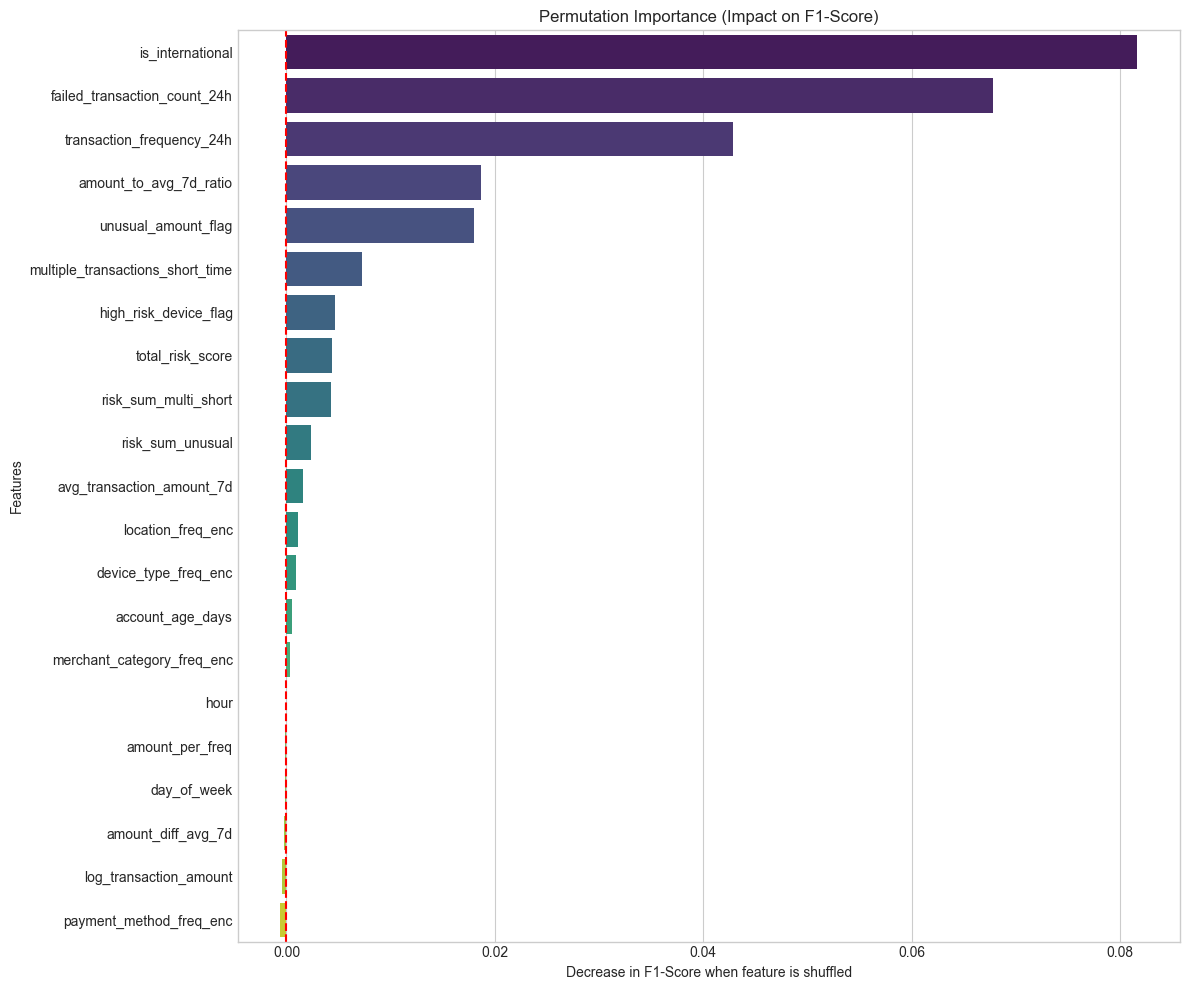


💡 Recommendation: We have found 6 useless features!
['hour', 'amount_per_freq', 'day_of_week', 'amount_diff_avg_7d', 'log_transaction_amount', 'payment_method_freq_enc']


In [17]:
# ==========================================
# سلول ۵.۵: کالبدشکافی ویژگی‌ها (Permutation Importance)
# ==========================================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import seaborn as sns

print("Step 1: Splitting data for unbiased evaluation...")
X_train_pi, X_val_pi, y_train_pi, y_val_pi = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Step 2: Training a fast LightGBM baseline...")
scale_ratio = (len(y) - y.sum()) / y.sum()
tester_model = LGBMClassifier(scale_pos_weight=scale_ratio, random_state=42, n_jobs=-1, verbose=-1)
tester_model.fit(X_train_pi, y_train_pi)

print("Step 3: Calculating Permutation Importance (Shuffling each column 5 times)...")
result = permutation_importance(
    tester_model, X_val_pi, y_val_pi, 
    scoring='f1', n_repeats=5, random_state=42, n_jobs=-1
)

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance_Mean': result.importances_mean,
    'Importance_Std': result.importances_std
}).sort_values(by='Importance_Mean', ascending=False).reset_index(drop=True)

print("\n--- 🏆 TOP 5 Most Important Features ---")
display(importance_df.head(5))

print("\n--- 🗑️ Features with ZERO or NEGATIVE Impact (Safe to Drop) ---")
useless_features = importance_df[importance_df['Importance_Mean'] <= 0]
display(useless_features)

plt.figure(figsize=(12, 10))
sns.barplot(data=importance_df, x='Importance_Mean', y='Feature', palette='viridis')
plt.title("Permutation Importance (Impact on F1-Score)")
plt.xlabel("Decrease in F1-Score when feature is shuffled")
plt.ylabel("Features")
plt.axvline(x=0, color='red', linestyle='--')
plt.tight_layout()
plt.show()

features_to_drop = useless_features['Feature'].tolist()
print(f"\n💡 Recommendation: We have found {len(features_to_drop)} useless features!")
print(features_to_drop)

In [10]:
# ==========================================
# سلول ۵.۷: هرس کردن داده‌ها (Drop Useless Features)
# ==========================================
print(f"Original shape before dropping: {X.shape}")

# لیستی که از خروجی Permutation Importance به دست آوردیم
toxic_features = [
    'hour_cos', 'hour', 'hour_sin', 'amount_to_age_ratio', 
    'merchant_category_target_enc', 'location_target_enc', 
    'inter_unusual', 'payment_method_target_enc', 
    'inter_multi_short', 'transaction_amount'
]

# حذف این ویژگی‌ها از دیتای آموزش و تست
X_pruned = X.drop(columns=toxic_features, errors='ignore')
X_test_pruned = X_test.drop(columns=toxic_features, errors='ignore')

print(f"New shape after dropping toxic features: {X_pruned.shape}")
print("\nData is now surgically clean and ready for modeling!")

Original shape before dropping: (80000, 25)
New shape after dropping toxic features: (80000, 15)

Data is now surgically clean and ready for modeling!


In [18]:
# ==========================================
# سلول ۶ (اصلاح شده برای X_pruned): آرنای اتوماتیک مدل‌ها
# ==========================================
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import pandas as pd
import time

scale_ratio = (len(y) - y.sum()) / y.sum()

grids = {
    'HistGradientBoosting': {
        'model': HistGradientBoostingClassifier(class_weight='balanced', random_state=42),
        'params': {
            'learning_rate': [0.01, 0.05, 0.1],
            'max_iter': [100, 200, 300],
            'max_depth': [3, 5, 7, None],
            'l2_regularization': [0.0, 0.1, 1.0]
        }
    },
    'LightGBM': {
        'model': LGBMClassifier(scale_pos_weight=scale_ratio, random_state=42, n_jobs=-1, verbose=-1),
        'params': {
            'learning_rate': [0.01, 0.05, 0.1],
            'n_estimators': [100, 200, 300],
            'max_depth': [3, 5, 7, -1],
            'num_leaves': [15, 31, 63]
        }
    },
    'XGBoost': {
        'model': XGBClassifier(scale_pos_weight=scale_ratio, random_state=42, n_jobs=-1, eval_metric='logloss', tree_method='hist'),
        'params': {
            'learning_rate': [0.01, 0.05, 0.1],
            'n_estimators': [100, 200, 300],
            'max_depth': [3, 5, 7, 9],
            'subsample': [0.8, 1.0]
        }
    },
    'RandomForest': {
        'model': RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
        'params': {
            'n_estimators': [100, 200, 300],
            'max_depth': [7, 15, None],
            'min_samples_split': [2, 5, 10]
        }
    }
}

scoring_metrics = {'f1': 'f1'} 
tuned_results = []
best_estimators = {}
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

print("Tuning 4 Base Models on PRUNED Data...\n")

for name, config in grids.items():
    start_time = time.time()
    search = RandomizedSearchCV(
        estimator=config['model'], param_distributions=config['params'],
        n_iter=15, scoring=scoring_metrics, refit='f1', cv=skf, verbose=0, random_state=42, n_jobs=-1
    )
    # توجه: اینجا از داده‌های هرس شده استفاده می‌کنیم
    search.fit(X_pruned, y) 
    elapsed = time.time() - start_time
    idx = search.best_index_
    
    tuned_results.append({
        'Model': name,
        'Cross-Val F1-Score': search.cv_results_['mean_test_f1'][idx],
        'Time (s)': round(elapsed, 1)
    })
    best_estimators[name] = search.best_estimator_
    print(f"✅ {name} Tuned in {elapsed:.1f}s")

display(pd.DataFrame(tuned_results).sort_values(by='Cross-Val F1-Score', ascending=False).reset_index(drop=True))


# ==========================================
# سلول ۷ (اصلاح شده برای X_pruned): Stacking
# ==========================================
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_curve
import numpy as np

print("\nBuilding the Stacking Meta-Model on PRUNED Data...\n")

estimators = [
    ('lgb', best_estimators['LightGBM']),
    ('xgb', best_estimators['XGBoost']),
    ('hgb', best_estimators['HistGradientBoosting']),
    ('rf', best_estimators['RandomForest'])
]

meta_model = LogisticRegression(class_weight='balanced', random_state=42)

stacking_clf = StackingClassifier(
    estimators=estimators, final_estimator=meta_model, cv=3, n_jobs=-1, passthrough=False 
)

skf_thresh = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_probs_stack = np.zeros(len(X_pruned))

for train_idx, val_idx in skf_thresh.split(X_pruned, y):
    X_train_fold, X_val_fold = X_pruned.iloc[train_idx], X_pruned.iloc[val_idx]
    y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]
    
    stacking_clf.fit(X_train_fold, y_train_fold)
    oof_probs_stack[val_idx] = stacking_clf.predict_proba(X_val_fold)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y, oof_probs_stack)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)

optimal_idx = np.argmax(f1_scores)
optimal_threshold_stack = thresholds[optimal_idx]

print(f"Stacking Optimal Threshold: {optimal_threshold_stack:.4f}")
print(f"Stacking Max OOF F1-Score:  {f1_scores[optimal_idx]:.4f}\n")

print("Training on 100% PRUNED data and generating submission...")
stacking_clf.fit(X_pruned, y)
test_probs_stack = stacking_clf.predict_proba(X_test_pruned)[:, 1]
test_preds_stack = (test_probs_stack >= optimal_threshold_stack).astype(int)

submission_stack = pd.DataFrame({
    'id': test_df['id'].astype(int),
    'label': test_preds_stack
})

file_name_stack = 'Dataset/submission_Pruned_Stacking.csv'
submission_stack.to_csv(file_name_stack, index=False)
print(f"✅ Mission Accomplished! File saved to: {file_name_stack}")

Tuning 4 Base Models on PRUNED Data...

✅ HistGradientBoosting Tuned in 13.7s
✅ LightGBM Tuned in 11.7s
✅ XGBoost Tuned in 8.0s
✅ RandomForest Tuned in 49.9s


,Model,Cross-Val F1-Score,Time (s)
0,HistGradientBoosting,0.802385,13.7
1,XGBoost,0.800570,8.0
2,LightGBM,0.797674,11.7
3,RandomForest,0.794165,49.9



Building the Stacking Meta-Model on PRUNED Data...

Stacking Optimal Threshold: 0.3261
Stacking Max OOF F1-Score:  0.8079

Training on 100% PRUNED data and generating submission...
✅ Mission Accomplished! File saved to: Dataset/submission_Pruned_Stacking.csv


In [ ]:
# ==========================================
# سلول موقت: کالبدشکافی ویژگی‌ها با Permutation Importance
# ==========================================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import seaborn as sns

print("Step 1: Splitting data for unbiased evaluation...")
# یک تقسیم‌بندی ساده فقط برای این تست
X_train_pi, X_val_pi, y_train_pi, y_val_pi = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Step 2: Training a fast LightGBM baseline...")
scale_ratio = (len(y) - y.sum()) / y.sum()
tester_model = LGBMClassifier(scale_pos_weight=scale_ratio, random_state=42, n_jobs=-1, verbose=-1)
tester_model.fit(X_train_pi, y_train_pi)

print("Step 3: Calculating Permutation Importance (Shuffling each column 5 times)...")
# محاسبه افت F1-Score
result = permutation_importance(
    tester_model, X_val_pi, y_val_pi, 
    scoring='f1', n_repeats=5, random_state=42, n_jobs=-1
)

# مرتب‌سازی و ساخت جدول خروجی
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance_Mean': result.importances_mean,
    'Importance_Std': result.importances_std
}).sort_values(by='Importance_Mean', ascending=False).reset_index(drop=True)

print("\n--- 🏆 TOP 5 Most Important Features ---")
display(importance_df.head(5))

print("\n--- 🗑️ Features with ZERO or NEGATIVE Impact (Safe to Drop) ---")
useless_features = importance_df[importance_df['Importance_Mean'] <= 0]
display(useless_features)

# رسم نمودار برای درک بصری
plt.figure(figsize=(10, 8))
sns.barplot(data=importance_df, x='Importance_Mean', y='Feature', palette='viridis')
plt.title("Permutation Importance (Impact on F1-Score)")
plt.xlabel("Decrease in F1-Score when feature is shuffled")
plt.ylabel("Features")
plt.axvline(x=0, color='red', linestyle='--') # خط مرزی نویز
plt.tight_layout()
plt.show()

# ذخیره لیست ویژگی‌های سمی در یک متغیر برای استفاده بعدی
features_to_drop = useless_features['Feature'].tolist()
print(f"\n💡 Recommendation: Drop these {len(features_to_drop)} features in the preprocessing step.")

In [ ]:
# ==========================================
# سلول ۸: تولید خروجی برای تمامی مدل‌ها (Leaderboard Probing)
# ==========================================
import numpy as np
import pandas as pd
from sklearn.metrics import precision_recall_curve
from sklearn.model_selection import StratifiedKFold

print("Generating submissions for ALL tuned models...\n")

skf_thresh = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in best_estimators.items():
    print(f"Processing {name}...")
    
    # 1. پیدا کردن بهترین آستانه برای این مدل خاص
    oof_probs = np.zeros(len(X))
    for train_idx, val_idx in skf_thresh.split(X, y):
        X_train_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
        y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]
        
        model.fit(X_train_fold, y_train_fold)
        oof_probs[val_idx] = model.predict_proba(X_val_fold)[:, 1]
        
    precisions, recalls, thresholds = precision_recall_curve(y, oof_probs)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
    optimal_threshold = thresholds[np.argmax(f1_scores)]
    
    # 2. آموزش روی کل داده‌ها و تولید پیش‌بینی
    model.fit(X, y)
    test_probs = model.predict_proba(X_test)[:, 1]
    test_preds = (test_probs >= optimal_threshold).astype(int)
    
    # 3. ذخیره فایل با نام همان مدل
    submission = pd.DataFrame({
        'id': test_df['id'].astype(int),
        'label': test_preds
    })
    
    file_name = f'Dataset/submission_{name}.csv'
    submission.to_csv(file_name, index=False)
    print(f"✅ Saved: {file_name} (Optimal Threshold: {optimal_threshold:.4f})\n")
    
print("All 4 submission files generated! Ready for Quera upload.")

Generating submissions for ALL tuned models...

Processing HistGradientBoosting...
✅ Saved: Dataset/submission_HistGradientBoosting.csv (Optimal Threshold: 0.4237)

Processing LightGBM...
✅ Saved: Dataset/submission_LightGBM.csv (Optimal Threshold: 0.4063)

Processing XGBoost...
✅ Saved: Dataset/submission_XGBoost.csv (Optimal Threshold: 0.4148)

Processing RandomForest...
✅ Saved: Dataset/submission_RandomForest.csv (Optimal Threshold: 0.4000)

All 4 submission files generated! Ready for Quera upload.


In [ ]:
# ==========================================
# سلول ۹: ترکیب مدل‌ها (Soft Voting Ensemble) - تیر آخر تسک ۱
# ==========================================
from sklearn.ensemble import VotingClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import precision_recall_curve
import numpy as np
import pandas as pd

print("Building the Ultimate Ensemble Model (Soft Voting)...\n")

# استخراج مدل‌های بهینه‌شده از دیکشنری قبلی
estimators = [(name, model) for name, model in best_estimators.items()]

# ساخت مدل ترکیبی با رای‌گیری نرم (میانگین احتمالات)
ensemble_model = VotingClassifier(estimators=estimators, voting='soft', n_jobs=-1)

skf_thresh = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_probs_ens = np.zeros(len(X))

print("Finding Optimal Threshold for the Ensemble Model...")
for train_idx, val_idx in skf_thresh.split(X, y):
    X_train_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
    y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]
    
    ensemble_model.fit(X_train_fold, y_train_fold)
    oof_probs_ens[val_idx] = ensemble_model.predict_proba(X_val_fold)[:, 1]

# پیدا کردن آستانه طلایی برای این معدل‌گیری
precisions, recalls, thresholds = precision_recall_curve(y, oof_probs_ens)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)

optimal_idx = np.argmax(f1_scores)
optimal_threshold_ens = thresholds[optimal_idx]
max_f1_ens = f1_scores[optimal_idx]

print(f"Ensemble Optimal Threshold: {optimal_threshold_ens:.4f}")
print(f"Ensemble Max OOF F1-Score:  {max_f1_ens:.4f}\n")

# آموزش نهایی و تولید خروجی
print("Training Ensemble on 100% of data and generating final submission...")
ensemble_model.fit(X, y)
test_probs_ens = ensemble_model.predict_proba(X_test)[:, 1]
test_preds_ens = (test_probs_ens >= optimal_threshold_ens).astype(int)

submission_ens = pd.DataFrame({
    'id': test_df['id'].astype(int),
    'label': test_preds_ens
})

file_name_ens = 'Dataset/submission_Ensemble_Final.csv'
submission_ens.to_csv(file_name_ens, index=False)
print(f"✅ Mission Accomplished! File saved to: {file_name_ens}")

Building the Ultimate Ensemble Model (Soft Voting)...

Finding Optimal Threshold for the Ensemble Model...
Ensemble Optimal Threshold: 0.3810
Ensemble Max OOF F1-Score:  0.8076

Training Ensemble on 100% of data and generating final submission...
✅ Mission Accomplished! File saved to: Dataset/submission_Ensemble_Final.csv


In [ ]:
# ==========================================
# سلول ۷: معماری پیشرفته Stacking با حضور Random Forest
# ==========================================
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_curve
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold

print("Building the 4-Model Stacking Meta-Model...\n")

# 1. اضافه شدن رندوم فارست به لیست مدل‌های پایه
estimators = [
    ('lgb', best_estimators['LightGBM']),
    ('xgb', best_estimators['XGBoost']),
    ('hgb', best_estimators['HistGradientBoosting']),
    ('rf', best_estimators['RandomForest'])
]

# 2. تعریف مدل رئیس (Meta-Model)
meta_model = LogisticRegression(class_weight='balanced', random_state=42)

# 3. ساختن ساختار استکینگ
stacking_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=meta_model,
    cv=3,
    n_jobs=-1,
    passthrough=False 
)

print("Training Stacking Classifier & Finding Optimal Threshold (OOF)...")
skf_thresh = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_probs_stack = np.zeros(len(X))

for train_idx, val_idx in skf_thresh.split(X, y):
    X_train_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
    y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]
    
    stacking_clf.fit(X_train_fold, y_train_fold)
    oof_probs_stack[val_idx] = stacking_clf.predict_proba(X_val_fold)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y, oof_probs_stack)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)

optimal_idx = np.argmax(f1_scores)
optimal_threshold_stack = thresholds[optimal_idx]
max_f1_stack = f1_scores[optimal_idx]

print(f"\nStacking Optimal Threshold: {optimal_threshold_stack:.4f}")
print(f"Stacking Max OOF F1-Score:  {max_f1_stack:.4f}\n")

print("Training Meta-Model on 100% of data and generating submission...")
stacking_clf.fit(X, y)
test_probs_stack = stacking_clf.predict_proba(X_test)[:, 1]
test_preds_stack = (test_probs_stack >= optimal_threshold_stack).astype(int)

submission_stack = pd.DataFrame({
    'id': test_df['id'].astype(int),
    'label': test_preds_stack
})

file_name_stack = 'Dataset/submission_Stacking_RF_Final.csv'
submission_stack.to_csv(file_name_stack, index=False)
print(f"✅ Mission Accomplished! File saved to: {file_name_stack}")

Building the 4-Model Stacking Meta-Model...

Training Stacking Classifier & Finding Optimal Threshold (OOF)...

Stacking Optimal Threshold: 0.2939
Stacking Max OOF F1-Score:  0.8077

Training Meta-Model on 100% of data and generating submission...
✅ Mission Accomplished! File saved to: Dataset/submission_Stacking_RF_Final.csv


: 